In [ ]:
#---data importing---
import pandas as pd

df = pd.read_csv("data/dreaddit-train.csv")
print(df.head())
print(df.info())

          subreddit post_id sentence_range  \
0              ptsd  8601tu       (15, 20)   
1        assistance  8lbrx9         (0, 5)   
2              ptsd  9ch1zh       (15, 20)   
3     relationships  7rorpp        [5, 10]   
4  survivorsofabuse  9p2gbc         [0, 5]   

                                                text     id  label  \
0  He said he had not felt that way before, sugge...  33181      1   
1  Hey there r/assistance, Not sure if this is th...   2606      0   
2  My mom then hit me with the newspaper and it s...  38816      1   
3  until i met my new boyfriend, he is amazing, h...    239      1   
4  October is Domestic Violence Awareness Month a...   1421      1   

   confidence  social_timestamp  social_karma  syntax_ari  ...  \
0         0.8        1521614353             5    1.806818  ...   
1         1.0        1527009817             4    9.429737  ...   
2         0.8        1535935605             2    7.769821  ...   
3         0.6        1516429555       

In [27]:
print(df.isnull().sum())

df = df.dropna()

subreddit                   0
post_id                     0
sentence_range              0
text                        0
id                          0
                           ..
lex_dal_avg_pleasantness    0
social_upvote_ratio         0
social_num_comments         0
syntax_fk_grade             0
sentiment                   0
Length: 116, dtype: int64


In [ ]:
# data cleaning
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+', '', text)  # remove links
    text = re.sub(r'[^a-zA-Z ]', '', text)  # remove special chars
    return text

df['text'] = df['text'].apply(clean_text)

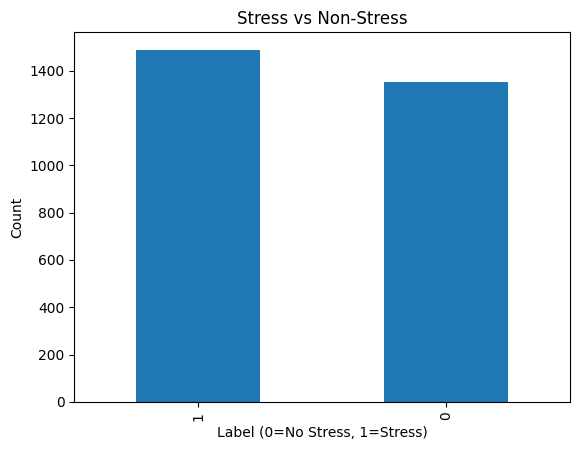

In [29]:
import matplotlib.pyplot as plt

df['label'].value_counts().plot(kind='bar')
plt.title("Stress vs Non-Stress")
plt.xlabel("Label (0=No Stress, 1=Stress)")
plt.ylabel("Count")
plt.show()

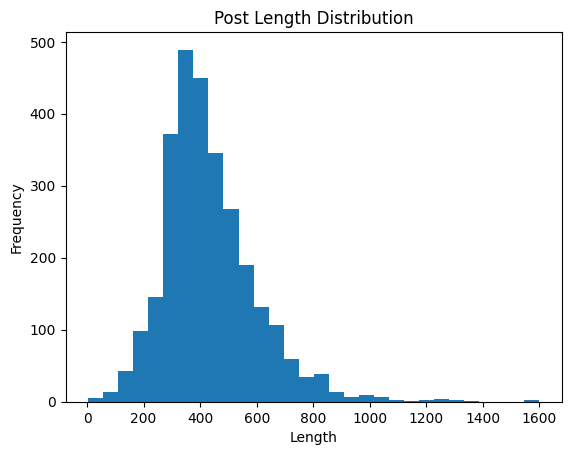

In [30]:
df['length'] = df['text'].apply(len)

plt.hist(df['length'], bins=30)
plt.title("Post Length Distribution")
plt.xlabel("Length")
plt.ylabel("Frequency")
plt.show()

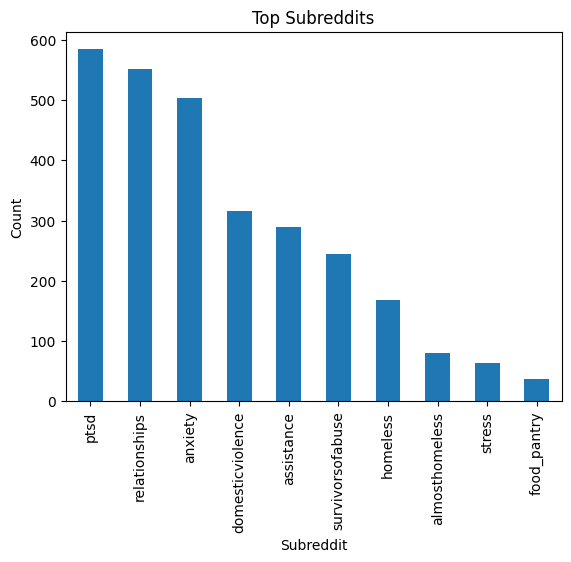

In [31]:
df['subreddit'].value_counts().head(10).plot(kind='bar')
plt.title("Top Subreddits")
plt.xlabel("Subreddit")
plt.ylabel("Count")
plt.show()

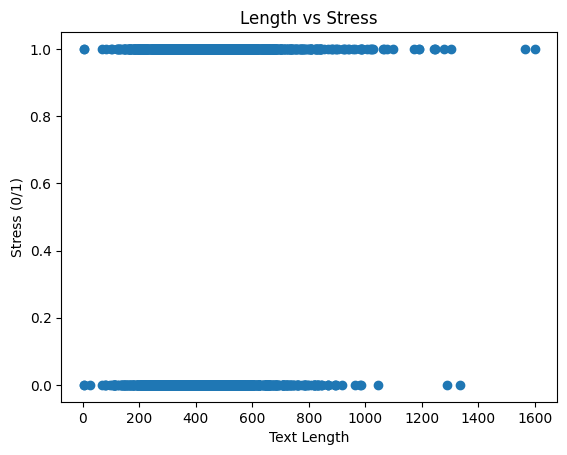

In [32]:
plt.scatter(df['length'], df['label'])
plt.xlabel("Text Length")
plt.ylabel("Stress (0/1)")
plt.title("Length vs Stress")
plt.show()

In [ ]:
#summary satistics
# Mean and Median for Numerical Data
print("--- Text Length Statistics ---")
print(f"Mean Length: {df['length'].mean():.2f}")
print(f"Median Length: {df['length'].median():.2f}")

print("\n--- Sentiment Statistics ---")
print(f"Mean Sentiment Score: {df['sentiment'].mean():.4f}")

#  Mode for Categorical Data
print("\n--- Frequency Statistics (Mode) ---")
print(f"Most Frequent Subreddit: {df['subreddit'].mode()[0]}")
print(f"Most Common Label: {df['label'].mode()[0]} (1=Stress, 0=No Stress)")

# Summary Table
print("\n--- General Summary ---")
print(df[['length', 'sentiment', 'confidence']].describe())

--- Text Length Statistics ---
Mean Length: 432.98
Median Length: 407.00

--- Sentiment Statistics ---
Mean Sentiment Score: 0.0407

--- Frequency Statistics (Mode) ---
Most Frequent Subreddit: ptsd
Most Common Label: 1 (1=Stress, 0=No Stress)

--- General Summary ---
            length    sentiment   confidence
count  2838.000000  2838.000000  2838.000000
mean    432.975335     0.040740     0.808972
std     165.270750     0.195490     0.177038
min       4.000000    -1.000000     0.428571
25%     326.000000    -0.072222     0.600000
50%     407.000000     0.044821     0.800000
75%     512.000000     0.166667     1.000000
max    1599.000000     1.000000     1.000000


In [ ]:
#small ai model
from sklearn.feature_extraction.text import TfidfVectorizer

#converting tesxt into numbers
vectorizer = TfidfVectorizer(max_features=500)

X = vectorizer.fit_transform(df['text']).toarray()
y = df['label']

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [36]:
from sklearn.linear_model import LogisticRegression

# Create and train the Logistic Regression model
model = LogisticRegression()
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [37]:
# This uses the model you trained in the previous cell to predict the test data
y_pred = model.predict(X_test)

# Optional: Print the first 5 predictions to see if it's working (0 or 1)
print("First 5 predictions:", y_pred[:5])

First 5 predictions: [1 0 0 0 0]


In [38]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Calculate Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

# Show the detailed report
print("\nDetailed Analysis:")
print(classification_report(y_test, y_pred))

Model Accuracy: 75.88%

Detailed Analysis:
              precision    recall  f1-score   support

           0       0.71      0.74      0.72       242
           1       0.80      0.77      0.79       326

    accuracy                           0.76       568
   macro avg       0.75      0.76      0.75       568
weighted avg       0.76      0.76      0.76       568



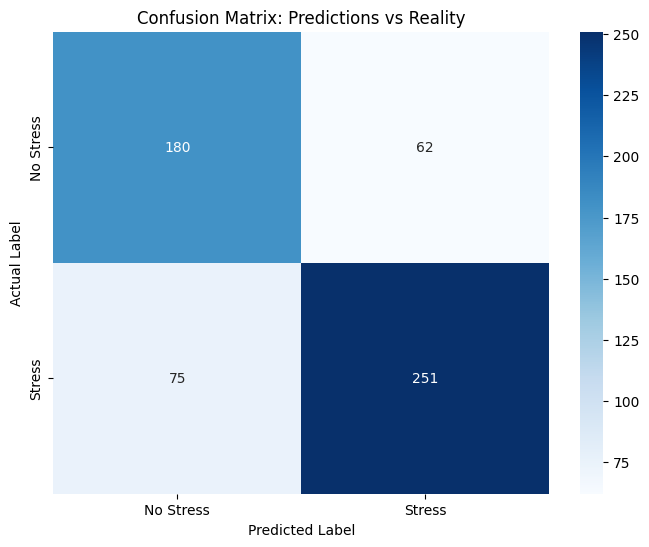

In [39]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Create the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# 2. Plot it using Seaborn for a "heatmap" look
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Stress', 'Stress'], 
            yticklabels=['No Stress', 'Stress'])

plt.title('Confusion Matrix: Predictions vs Reality')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()